# Sales Analytics Project

## 1. Data Loading and Initial Inspection

This project analyzes retail sales data to identify revenue trends, customer behavior, product performance, and business insights.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("../DATA/Superstore.csv")

In [10]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
df.shape

(9994, 21)

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [13]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [14]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## 2. Data Understanding and Quality Assessment

### Dataset Summary

The dataset contains 9,994 retail transactions and 21 variables related to orders, customers, products, sales, discounts, and profit.

### Data Quality Findings

- No missing values were detected.
- Sales and profit are continuous numerical variables.
- The dataset contains customer, product, geographical, and transactional information.
- The dataset is suitable for business analytics and performance evaluation.

## 3. Revenue Analysis

In [20]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
avg_sales = df["Sales"].mean()
orders = df["Order ID"].nunique()

print(f"Total Revenue: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Average Sales per Transaction: ${avg_sales:,.2f}")
print(f"Unique Orders: {orders:,}")

Total Revenue: $2,297,200.86
Total Profit: $286,397.02
Average Sales per Transaction: $229.86
Unique Orders: 5,009


### Revenue Overview

The company generated a total revenue of $2.30 million and a total profit of $286.40 thousand.

The average sales value per transaction was approximately $229.86.

A total of 5,009 unique orders were recorded in the dataset.

These figures indicate strong business activity and provide a solid foundation for further analysis of products, customers, and regional performance.

## 4. Revenue by Category Analysis

In [21]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values()

category_sales

Category
Office Supplies    719047.0320
Furniture          741999.7953
Technology         836154.0330
Name: Sales, dtype: float64

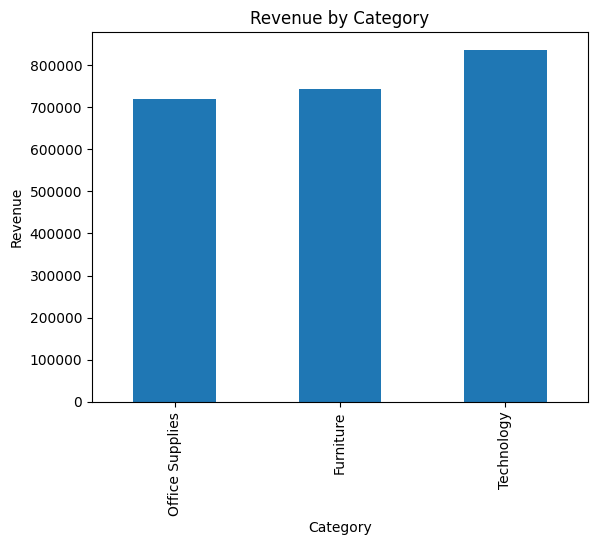

In [22]:
category_sales.plot(kind="bar")

plt.title("Revenue by Category")
plt.ylabel("Revenue")

plt.savefig("../OUTPUTS/revenue_by_category.png")

plt.show()

### Revenue by Category

This analysis evaluates the contribution of each product category to overall revenue generation.

The comparison helps identify which categories drive the largest share of company sales.

In [23]:
(category_sales / category_sales.sum() * 100).round(2)

Category
Office Supplies    31.3
Furniture          32.3
Technology         36.4
Name: Sales, dtype: float64

### Revenue by Category Findings

Technology generated the highest revenue among all product categories, contributing approximately one-third of total company sales.

Furniture ranked second in revenue generation, while Office Supplies contributed the lowest revenue.

The relatively balanced revenue distribution suggests that the business does not rely heavily on a single category, although Technology appears to be the strongest revenue driver.

## 5. Profit Analysis

In [24]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values()

category_profit

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

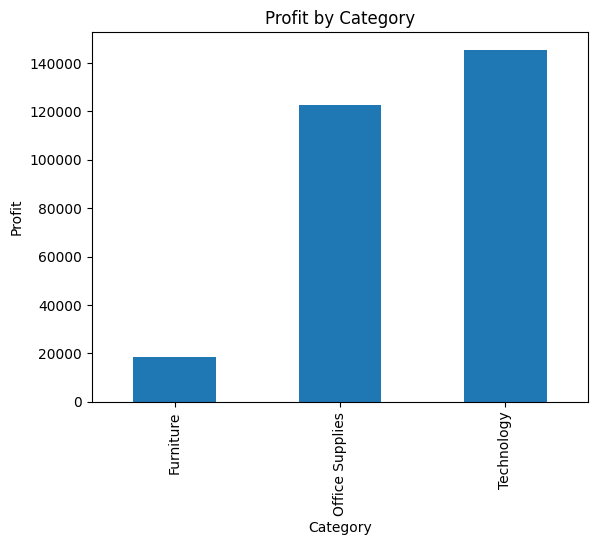

In [25]:
category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.ylabel("Profit")

plt.savefig("../OUTPUTS/profit_by_category.png")

plt.show()

In [26]:
profit_margin = (
    df.groupby("Category")["Profit"].sum()
    /
    df.groupby("Category")["Sales"].sum()
) * 100

profit_margin.round(2)

Category
Furniture           2.49
Office Supplies    17.04
Technology         17.40
dtype: float64

### Profit Analysis Findings

Technology generated the highest profit among all categories, contributing approximately $145,455 to overall company profitability.

Office Supplies ranked second with a profit of approximately $122,491, while Furniture generated only $18,452 despite contributing substantial revenue.

The large gap between Furniture revenue and profit suggests that this category operates with significantly lower margins compared to the other categories.

### Profit Margin Findings

Technology achieved the highest profit margin at approximately 17.4%, closely followed by Office Supplies at 17.0%.

Furniture showed a very low profit margin of only 2.5%, indicating that a large portion of its revenue is consumed by operational costs, discounts, or lower markups.

Although Furniture contributes significantly to revenue, it is considerably less efficient in generating profit compared to Technology and Office Supplies.

### Business Recommendation

Technology should remain a strategic focus area due to its strong performance in both revenue generation and profitability.

Office Supplies demonstrates healthy profitability and represents a stable source of business income.

Furniture requires further investigation to identify factors affecting profitability, such as excessive discounting, high procurement costs, or inefficient pricing strategies.

## 6. Regional Sales Analysis

In [27]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values()

region_sales

Region
South      391721.9050
Central    501239.8908
East       678781.2400
West       725457.8245
Name: Sales, dtype: float64

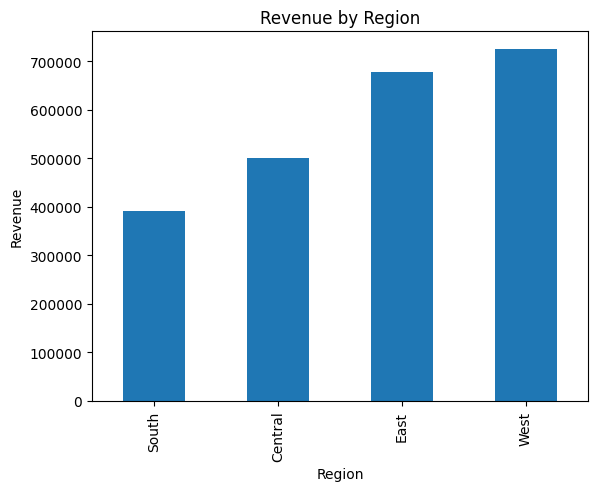

In [28]:
region_sales.plot(kind="bar")

plt.title("Revenue by Region")
plt.ylabel("Revenue")

plt.savefig("../OUTPUTS/revenue_by_region.png")

plt.show()

### Regional Revenue Findings

The West region generated the highest revenue, contributing approximately $725,458 in sales.

The East region ranked second with total sales of approximately $678,781.

The Central region generated moderate revenue of approximately $501,240, while the South region recorded the lowest sales at approximately $391,722.

The substantial gap between the West and South regions indicates significant differences in market performance across geographical areas.

### Business Insights

The West region appears to be the company's strongest market and should remain a key focus for future growth initiatives.

The East region also demonstrates strong performance and represents another major revenue contributor.

The South region presents an opportunity for business expansion, as its revenue is considerably lower than the other regions.

Further investigation into customer demand, product mix, and marketing effectiveness across regions may help explain these performance differences.

## 7. Top Performing States

In [29]:
state_sales = (
    df.groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_sales

State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Florida          89473.7080
Illinois         80166.1010
Ohio             78258.1360
Michigan         76269.6140
Virginia         70636.7200
Name: Sales, dtype: float64

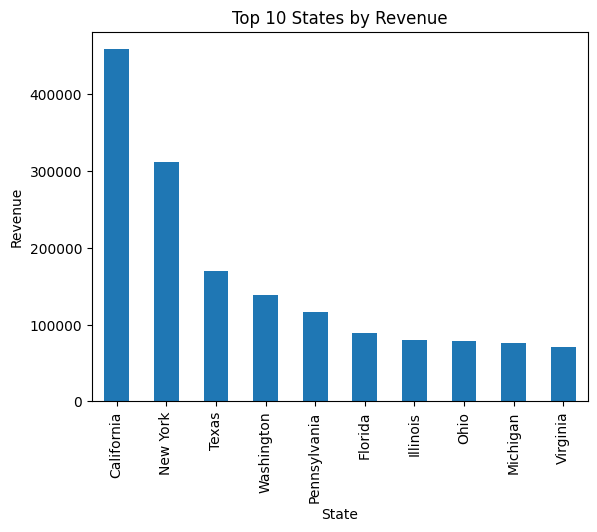

In [30]:
state_sales.plot(kind="bar")

plt.title("Top 10 States by Revenue")
plt.ylabel("Revenue")

plt.savefig("../OUTPUTS/top_10_states_revenue.png")

plt.show()

### Top States Revenue Findings

California generated the highest revenue, contributing approximately $457,688 in sales.

New York ranked second with approximately $310,877 in revenue, while Texas occupied the third position with approximately $170,188.

California's revenue is significantly higher than all other states, indicating that it is the company's most important market.

The top three states contribute a substantial share of total company revenue and should be considered strategic markets.

### Business Insights

California should remain a primary focus area for customer retention and business expansion strategies.

New York demonstrates strong sales performance and represents another major revenue-generating market.

States with lower revenue among the top ten, such as Virginia and Michigan, may offer opportunities for targeted marketing campaigns and customer acquisition initiatives.

Understanding the factors driving California's exceptional performance could help replicate similar success in other states.

## 8. Customer Analysis

In [31]:
top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

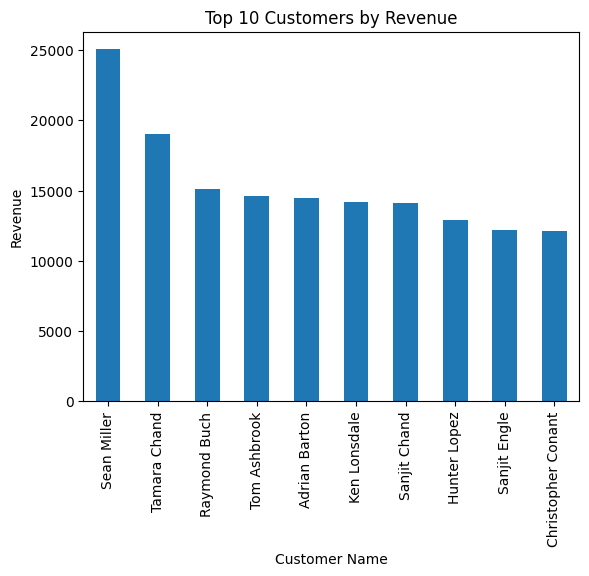

In [32]:
top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Revenue")
plt.ylabel("Revenue")

plt.savefig("../OUTPUTS/top_customers_revenue.png")

plt.show()

In [33]:
top_customers.sum() / df["Sales"].sum() * 100

np.float64(6.6955907799857455)

### Top Customer Findings

Sean Miller was the highest revenue-generating customer, contributing approximately $25,043 in sales.

Tamara Chand ranked second with approximately $19,652 in revenue, followed by Raymond Buch with approximately $15,177.

The top ten customers collectively generated approximately 6.70% of total company revenue.

This indicates that company revenue is not heavily dependent on a small number of customers and is instead distributed across a broad customer base.

### Customer Insights

The relatively low contribution of the top ten customers suggests a diversified customer portfolio, reducing revenue concentration risk.

Maintaining strong relationships with high-value customers remains important, as they contribute significantly more revenue than the average customer.

Customer retention programs targeting top-performing customers may further increase long-term revenue and profitability.

## 9. Product Analysis

In [34]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

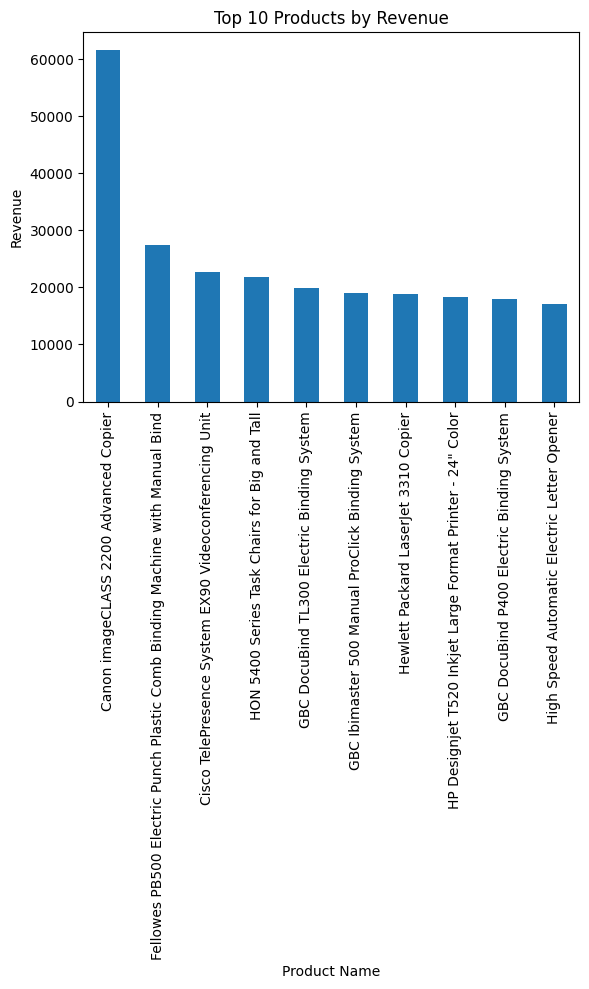

In [35]:
top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")

plt.savefig("../OUTPUTS/top_products_revenue.png")

plt.show()

In [36]:
top_products.sum() / df["Sales"].sum() * 100

np.float64(10.64862059855115)

### Product Revenue Findings

The Canon imageCLASS 2200 Advanced Copier generated the highest revenue among all products, contributing approximately $61,600 in sales.

The second-highest revenue-generating product was the Fellowes PB500 Electric Punch Plastic Comb Binding Machine, generating approximately $27,453 in revenue.

The top ten products collectively contributed approximately 10.65% of total company revenue.

This indicates that a relatively small number of products generate a significant share of sales, highlighting the importance of monitoring top-performing products.

### Product Insights

The Canon imageCLASS 2200 Advanced Copier significantly outperformed all other products, generating more than double the revenue of the second-ranked product.

The company's revenue appears to be partially concentrated among a small set of high-performing products.

Inventory management and marketing efforts should prioritize these top-performing products to maximize revenue generation.

Further analysis of profit margins for these products would help determine whether high sales are also translating into high profitability.

## 10. Discount vs Profit Analysis

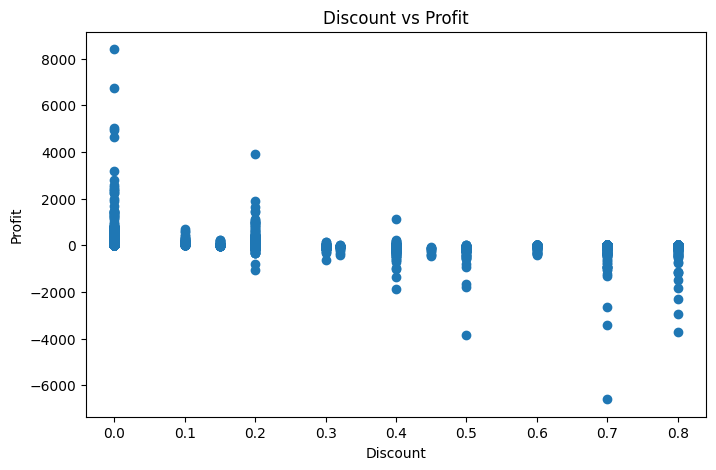

In [37]:
plt.figure(figsize=(8,5))

plt.scatter(df["Discount"], df["Profit"])

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.savefig("../OUTPUTS/discount_vs_profit.png")

plt.show()

In [38]:
df[["Discount","Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


### Discount vs Profit Findings

The correlation between Discount and Profit is approximately -0.22, indicating a weak-to-moderate negative relationship.

The scatter plot shows that transactions with higher discounts are more likely to generate lower profits and, in some cases, substantial losses.

Most highly profitable transactions occur at low or zero discount levels, whereas heavily discounted transactions are frequently associated with reduced profitability.

These findings suggest that aggressive discounting may negatively impact overall business performance.

### Business Insights

The company should carefully evaluate discount strategies to ensure that revenue growth does not come at the expense of profitability.

High-discount transactions should be monitored to identify products or customer segments that consistently generate losses.

A more targeted discounting approach may improve profit margins while maintaining competitive pricing.

Balancing customer acquisition incentives with profitability objectives is essential for long-term business success.

# 11. Key Business Recommendations

## Key Business Recommendations

### 1. Focus on High-Performing Regions

The West and East regions generate the highest revenue and should remain priority markets for expansion and customer retention initiatives.

### 2. Strengthen Top Product Categories

Technology consistently demonstrates strong revenue and profitability performance and should remain a strategic focus area.

### 3. Improve Furniture Profitability

Although Furniture contributes significant revenue, its profit margin is substantially lower than other categories. Pricing and discount strategies should be reviewed.

### 4. Retain High-Value Customers

Top customers contribute a meaningful share of revenue. Targeted loyalty programs and customer engagement initiatives may improve retention.

### 5. Optimize Discount Strategies

Higher discounts are associated with lower profits. Discount policies should be carefully evaluated to avoid unnecessary profit erosion.

### 6. Expand Low-Performing Markets

The South region presents opportunities for revenue growth through targeted marketing and sales initiatives.

# 12. Project Conclusion

## Conclusion

This project analyzed approximately 10,000 retail transactions to identify sales trends, profitability drivers, customer behavior patterns, and regional performance differences.

Key findings revealed that Technology is the most profitable category, the West region generates the highest revenue, and a small group of products contributes significantly to overall sales performance.

Customer revenue is relatively diversified, reducing dependency on a small number of buyers. However, discounting practices show a negative impact on profitability and should be carefully managed.

The analysis demonstrates how data analytics can support business decision-making by uncovering actionable insights related to revenue growth, profitability improvement, customer management, and market expansion.